In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import json
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
def load_dataset(directory, image_size=(128, 128), batch_size=32, shuffle=True, seed=None):
    """Load and preprocess the dataset from directory"""
    return tf.keras.utils.image_dataset_from_directory(
        directory,
        labels="inferred",
        label_mode="categorical",
        batch_size=batch_size,
        image_size=image_size,
        shuffle=shuffle,
        seed=seed,
        interpolation="bilinear",
        verbose=True
    )

In [5]:
full_dataset = load_dataset('/content/drive/MyDrive/Corn/Corn/Corn_train')

Found 7316 files belonging to 4 classes.


In [6]:
from tqdm import tqdm

def dataset_to_numpy(dataset):
    """Convert TF Dataset to numpy arrays with a progress bar"""
    images, labels = [], []
    total_batches = tf.data.experimental.cardinality(dataset).numpy()

    for img, lbl in tqdm(dataset, total=total_batches, desc="Converting dataset"):
        images.append(img.numpy())
        labels.append(lbl.numpy())

    return np.concatenate(images), np.concatenate(labels)

# Usage
X, y = dataset_to_numpy(full_dataset)


Converting dataset: 100%|██████████| 229/229 [16:31<00:00,  4.33s/it]


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPool2D, Dropout,Flatten, Dense

def create_model(input_shape=(128, 128, 3), num_classes=4):
    """Create and compile the CNN model"""
    model = Sequential()
    return model

# Call the create_model function to initialize the model
input_shape = (128, 128, 3)  # Define input_shape
model = create_model(input_shape=input_shape) # Assign the created model to the variable 'model'

# Now you can add layers to the model
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=input_shape))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2, strides=2))
model.add(Dropout(0.25))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.25))

In [9]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.25))

In [10]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.25))

In [11]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.25))

In [12]:
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(4, activation='softmax'))

In [13]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
num_folds = 5
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=42)

In [15]:
fold_results = {
    'train_acc': [],
    'val_acc': [],
    'train_loss': [],
    'val_loss': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'histories': [],
    'confusion_matrices':[],
    'sensitivity': [], 'specificity': [], 'per_class_precision': [], 'accuracy': []
}

In [16]:
print(f"\nStarting {num_folds}-fold cross validation...\n")

for fold, (train_ids, val_ids) in enumerate(kfold.split(X, y)):
    print(f"\n{'='*40}")
    print(f"Training Fold {fold + 1}/{num_folds}")
    print(f"{'='*40}")

    X_train, y_train = X[train_ids], y[train_ids]
    X_val, y_val = X[val_ids], y[val_ids]

    train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32).prefetch(tf.data.AUTOTUNE)
    val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(32).prefetch(tf.data.AUTOTUNE)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint(
            f"best_model_fold_{fold+1}.keras",
            save_best_only=True,
            monitor='val_accuracy'
        )
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate on validation set for metrics
    y_val_pred_probs = model.predict(val_ds)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)

    y_val_true = np.concatenate([y for x, y in val_ds], axis=0)
    y_val_true = np.argmax(y_val_true, axis=1)

    cm = confusion_matrix(y_val_true, y_val_pred)
    fold_results['confusion_matrices'].append(cm)

    precision = precision_score(y_val_true, y_val_pred, average='macro')
    recall = recall_score(y_val_true, y_val_pred, average='macro')
    f1 = f1_score(y_val_true, y_val_pred, average='macro')

    # True Positives, False Positives, False Negatives, True Negatives
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (TP + FP + FN)

    sensitivity = TP / (TP + FN + 1e-10)  # Recall
    specificity = TN / (TN + FP + 1e-10)
    precision = TP / (TP + FP + 1e-10)
    accuracy = np.sum(TP) / np.sum(cm)


    # Save results
    fold_results['train_acc'].append(history.history['accuracy'][-1])
    fold_results['val_acc'].append(history.history['val_accuracy'][-1])
    fold_results['train_loss'].append(history.history['loss'][-1])
    fold_results['val_loss'].append(history.history['val_loss'][-1])
    fold_results['precision'].append(precision)
    fold_results['recall'].append(recall)
    fold_results['f1'].append(f1)
    fold_results['histories'].append(history.history)
    fold_results['sensitivity'].append(sensitivity)
    fold_results['specificity'].append(specificity)
    fold_results['per_class_precision'].append(precision)
    fold_results['accuracy'].append(accuracy)

    model.save(f"best_model_fold_{fold+1}.keras")



Starting 5-fold cross validation...


Training Fold 1/5
Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 58s 182ms/step - accuracy: 0.7596 - loss: 0.9614 - val_accuracy: 0.7575 - val_loss: 0.5793
Epoch 2/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 45s 71ms/step - accuracy: 0.9149 - loss: 0.2552 - val_accuracy: 0.8866 - val_loss: 0.3373
Epoch 3/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.9376 - loss: 0.1701 - val_accuracy: 0.9747 - val_loss: 0.0979
Epoch 4/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 20s 67ms/step - accuracy: 0.9596 - loss: 0.1158 - val_accuracy: 0.9454 - val_loss: 0.1634
Epoch 5/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9557 - loss: 0.1198 - val_accuracy: 0.6441 - val_loss: 2.5769
Epoch 6/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9589 - loss: 0.1210 - val_accuracy: 0.9392 - val_loss: 0.1867
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step

Training Fold 2/5
Epoch 1/20
183/183 ━━━━━━━━━━━━━━━━━━━━ 33s 175ms/step - accuracy: 0.9537 - loss: 0.1362 - val_accuracy

In [17]:
class_names = full_dataset.class_names
class_names

['Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy']


=== Average Metrics per Class over 5 Folds ===
Class Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot:
  Sensitivity (Recall): 0.9131
  Specificity        : 0.9835
  Precision          : 0.9417
Class Corn_(maize)___Common_rust_:
  Sensitivity (Recall): 0.9917
  Specificity        : 0.9995
  Precision          : 0.9984
Class Corn_(maize)___Northern_Leaf_Blight:
  Sensitivity (Recall): 0.9547
  Specificity        : 0.9757
  Precision          : 0.9344
Class Corn_(maize)___healthy:
  Sensitivity (Recall): 1.0000
  Specificity        : 0.9967
  Precision          : 0.9904

=== Overall Average Accuracy over 5 Folds ===
Average Accuracy: 0.9664

Detailed Cross Validation Metrics Per Fold:
------------------------------------------------------------
Fold 1:
  Train Accuracy     : 0.9605
  Validation Accuracy: 0.9392
  Train Loss         : 0.1279
  Validation Loss    : 0.1867
  Precision (macro)  : 0.9729
  Recall (macro)     : 0.9742
  F1-Score (macro)   : 0.9733
  Confusion Matrix:
[[305 

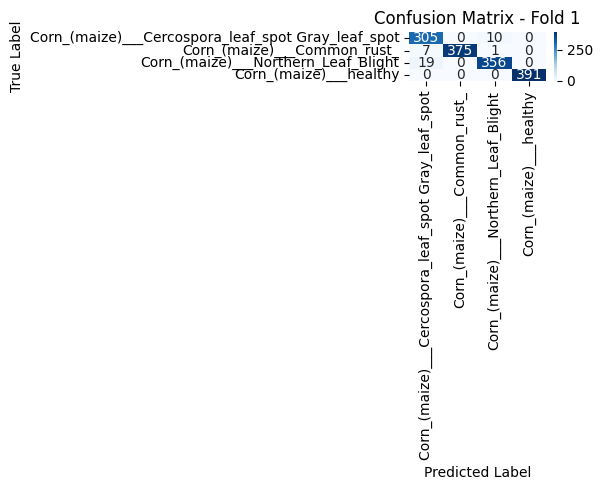

------------------------------------------------------------
Fold 2:
  Train Accuracy     : 0.9657
  Validation Accuracy: 0.9706
  Train Loss         : 0.1086
  Validation Loss    : 0.1288
  Precision (macro)  : 0.9692
  Recall (macro)     : 0.9664
  F1-Score (macro)   : 0.9673
  Confusion Matrix:
[[304   0  32   4]
 [  1 369   0   0]
 [  9   0 380   1]
 [  0   0   0 363]]


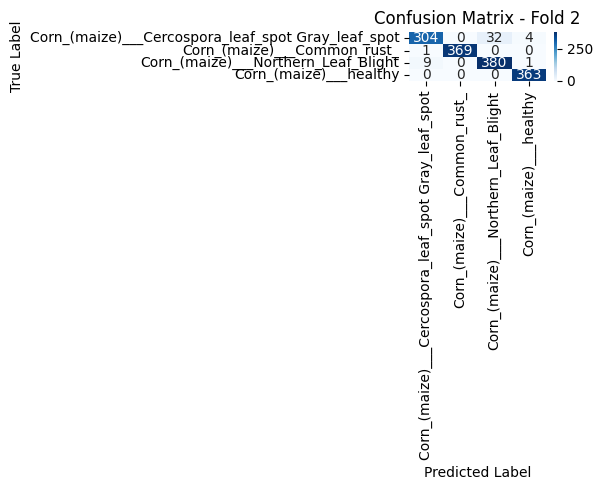

------------------------------------------------------------
Fold 3:
  Train Accuracy     : 0.9598
  Validation Accuracy: 0.8284
  Train Loss         : 0.1210
  Validation Loss    : 0.8642
  Precision (macro)  : 0.9603
  Recall (macro)     : 0.9579
  F1-Score (macro)   : 0.9588
  Confusion Matrix:
[[279   0  34   2]
 [  4 396   0   0]
 [ 16   0 389   2]
 [  0   0   0 341]]


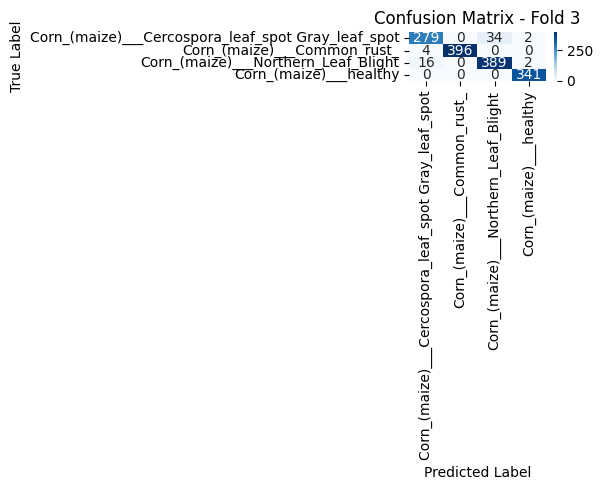

------------------------------------------------------------
Fold 4:
  Train Accuracy     : 0.9549
  Validation Accuracy: 0.9487
  Train Loss         : 0.1289
  Validation Loss    : 0.1304
  Precision (macro)  : 0.9674
  Recall (macro)     : 0.9642
  F1-Score (macro)   : 0.9647
  Confusion Matrix:
[[303   3  39   1]
 [  1 371   0   0]
 [  6   0 363   0]
 [  0   0   0 376]]


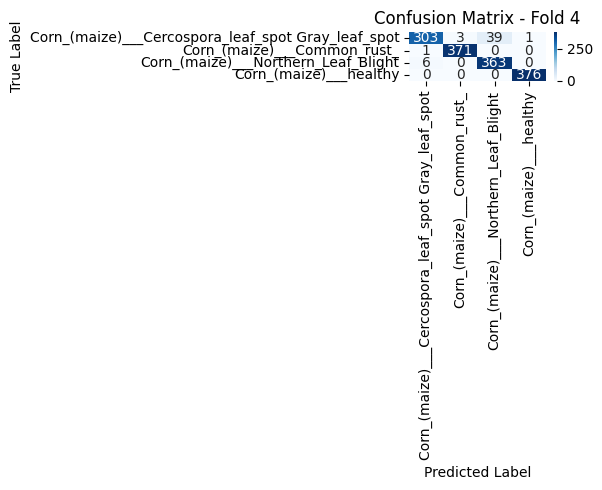

------------------------------------------------------------
Fold 5:
  Train Accuracy     : 0.9718
  Validation Accuracy: 0.9624
  Train Loss         : 0.0840
  Validation Loss    : 0.1320
  Precision (macro)  : 0.9613
  Recall (macro)     : 0.9616
  F1-Score (macro)   : 0.9612
  Confusion Matrix:
[[307   0  15   4]
 [  2 380   0   0]
 [ 29   0 334   4]
 [  0   0   0 388]]


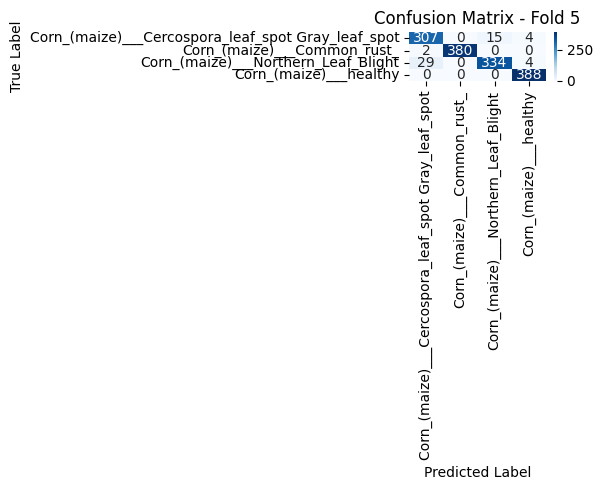

------------------------------------------------------------


In [18]:
# Convert lists to arrays
sensitivities = np.array(fold_results['sensitivity'])
specificities = np.array(fold_results['specificity'])
precisions_per_class = np.array(fold_results['per_class_precision'])
accuracies_per_fold = np.array(fold_results['accuracy'])

# Averages across folds
avg_sensitivity = np.mean(sensitivities, axis=0)
avg_specificity = np.mean(specificities, axis=0)
avg_precision_per_class = np.mean(precisions_per_class, axis=0)
avg_accuracy = np.mean(accuracies_per_fold)

# Display average metrics per class
print("\n=== Average Metrics per Class over 5 Folds ===")
for i, class_name in enumerate(class_names):
    print(f"Class {class_name}:")
    print(f"  Sensitivity (Recall): {avg_sensitivity[i]:.4f}")
    print(f"  Specificity        : {avg_specificity[i]:.4f}")
    print(f"  Precision          : {avg_precision_per_class[i]:.4f}")

# Overall accuracy
print(f"\n=== Overall Average Accuracy over 5 Folds ===")
print(f"Average Accuracy: {avg_accuracy:.4f}")
print("="*60)
# Detailed metrics per fold
print("\nDetailed Cross Validation Metrics Per Fold:")
print(f"{'-'*60}")
for i in range(num_folds):
    print(f"Fold {i+1}:")
    print(f"  Train Accuracy     : {fold_results['train_acc'][i]:.4f}")
    print(f"  Validation Accuracy: {fold_results['val_acc'][i]:.4f}")
    print(f"  Train Loss         : {fold_results['train_loss'][i]:.4f}")
    print(f"  Validation Loss    : {fold_results['val_loss'][i]:.4f}")
    print(f"  Precision (macro)  : {np.mean(fold_results['precision'][i]):.4f}")
    print(f"  Recall (macro)     : {fold_results['recall'][i]:.4f}")
    print(f"  F1-Score (macro)   : {fold_results['f1'][i]:.4f}")
    print("  Confusion Matrix:")
    cm = fold_results['confusion_matrices'][i]
    print(cm)

    # Plot confusion matrix for the current fold
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {i + 1}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

    print("-" * 60)


In [19]:
# Print summary
print("\nCross Validation Results Summary:")
print(f"{'-'*40}")
for metric in ['train_acc', 'val_acc', 'train_loss', 'val_loss', 'precision', 'recall', 'f1']:
    print(f"Average {metric.replace('_', ' ').title()}: {np.mean(fold_results[metric]):.4f} ± {np.std(fold_results[metric]):.4f}")



Cross Validation Results Summary:
----------------------------------------
Average Train Acc: 0.9625 ± 0.0058
Average Val Acc: 0.9299 ± 0.0519
Average Train Loss: 0.1141 ± 0.0167
Average Val Loss: 0.2884 ± 0.2887
Average Precision: 0.9662 ± 0.0341
Average Recall: 0.9649 ± 0.0055
Average F1: 0.9651 ± 0.0050


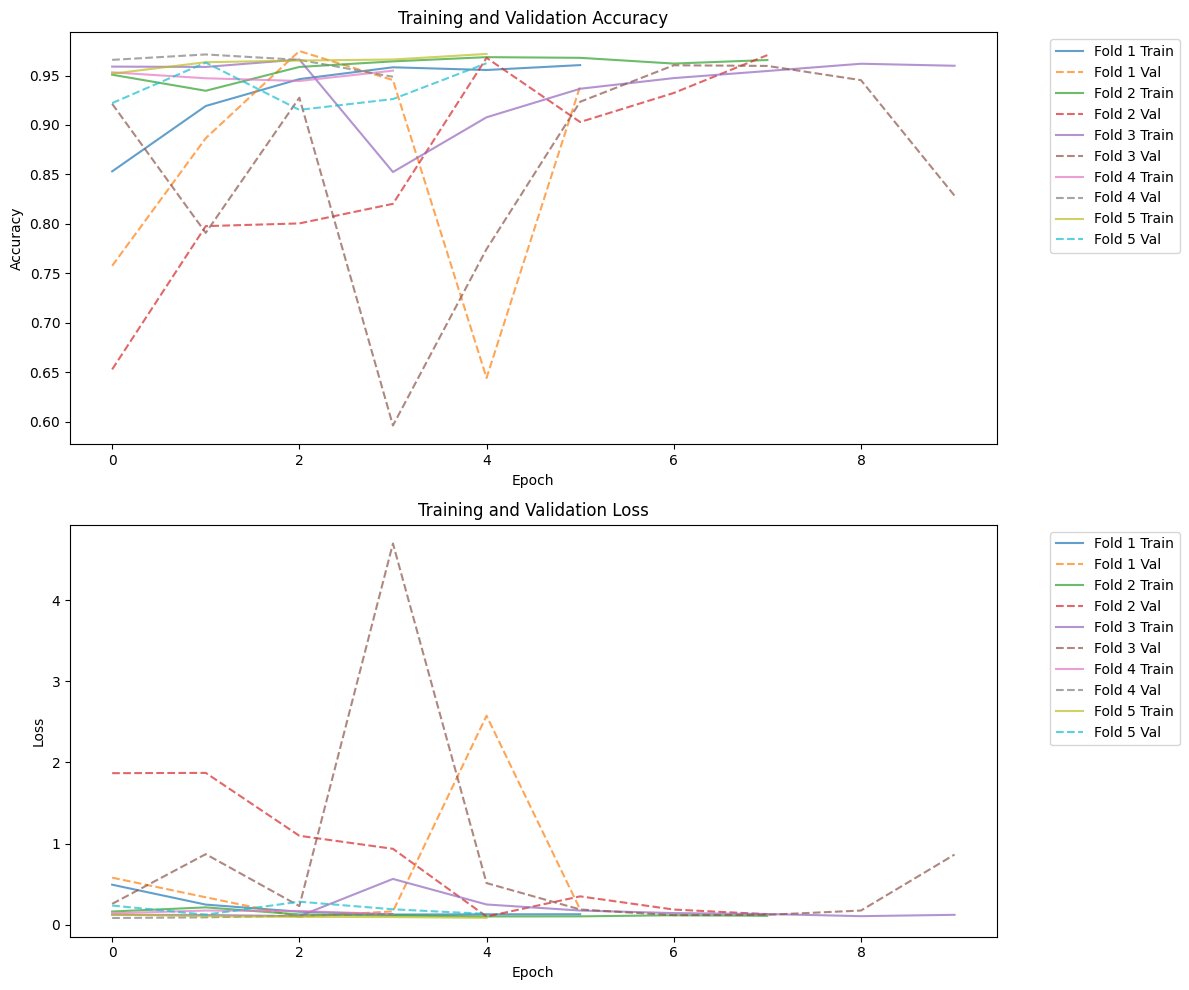

In [20]:
# Plot learning curves
def plot_learning_curves(histories):
    plt.figure(figsize=(12, 10))

    # Accuracy
    plt.subplot(2, 1, 1)
    for i, history in enumerate(histories):
        plt.plot(history['accuracy'], label=f'Fold {i+1} Train', alpha=0.7)
        plt.plot(history['val_accuracy'], '--', label=f'Fold {i+1} Val', alpha=0.7)
    plt.title('Training and Validation Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    # Loss
    plt.subplot(2, 1, 2)
    for i, history in enumerate(histories):
        plt.plot(history['loss'], label=f'Fold {i+1} Train', alpha=0.7)
        plt.plot(history['val_loss'], '--', label=f'Fold {i+1} Val', alpha=0.7)
    plt.title('Training and Validation Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_learning_curves(fold_results['histories'])


In [21]:
# Load best model based on val accuracy
best_fold = np.argmax(fold_results['val_acc'])
print(f'\nUsing model from fold {best_fold+1} (best validation accuracy) for final test evaluation')

best_model = tf.keras.models.load_model(f"best_model_fold_{best_fold+1}.keras")



Using model from fold 2 (best validation accuracy) for final test evaluation


In [22]:
# Test evaluation
test_set = tf.keras.utils.image_dataset_from_directory(
    '/content/drive/MyDrive/Corn/Corn/Corn_valid',
    labels="inferred",
    label_mode="categorical",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False
)

class_names = test_set.class_names
test_loss, test_acc = best_model.evaluate(test_set)
print(f'\nTest Accuracy: {test_acc:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Found 1829 files belonging to 4 classes.
58/58 ━━━━━━━━━━━━━━━━━━━━ 320s 4s/step - accuracy: 0.9215 - loss: 0.2340

Test Accuracy: 0.9601
Test Loss: 0.1670


In [23]:
y_pred = best_model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

print('\nClassification Report:')
print(classification_report(Y_true, predicted_categories, target_names=class_names))


58/58 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step

Classification Report:
                                                    precision    recall  f1-score   support

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.97      0.86      0.91       410
                       Corn_(maize)___Common_rust_       1.00      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.90      0.97      0.94       477
                            Corn_(maize)___healthy       0.98      1.00      0.99       465

                                          accuracy                           0.96      1829
                                         macro avg       0.96      0.96      0.96      1829
                                      weighted avg       0.96      0.96      0.96      1829



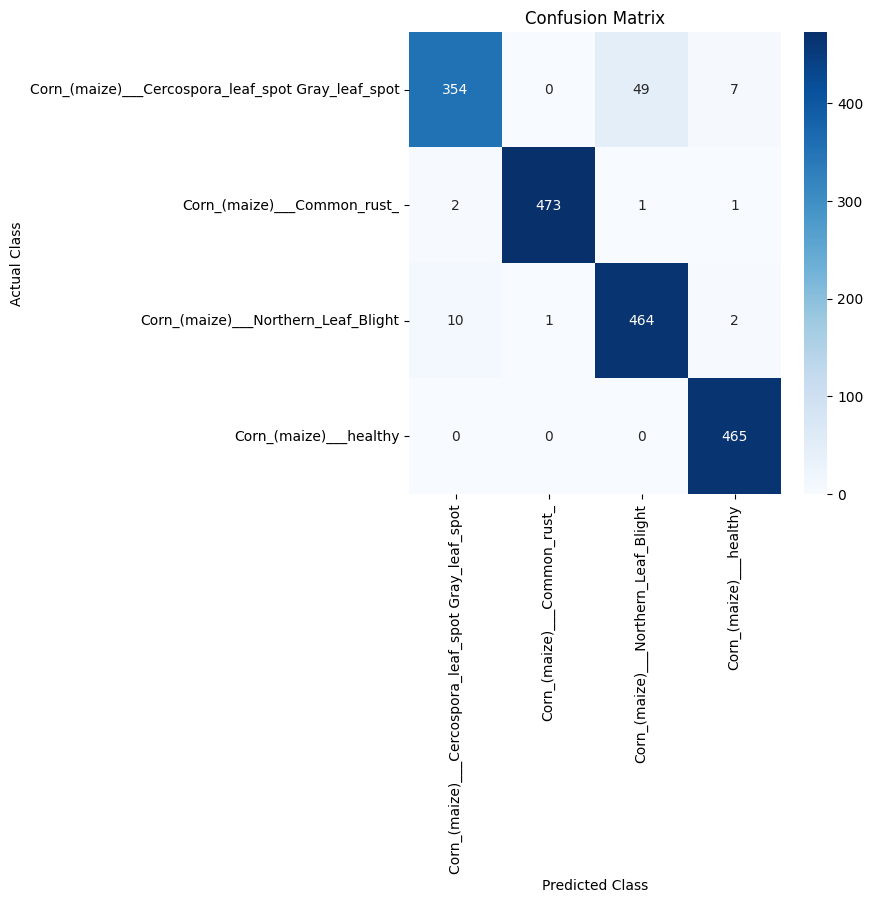

In [24]:
# Confusion matrix
cm = confusion_matrix(Y_true, predicted_categories)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()